## Baseline models

In [221]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)

from sklearn.linear_model import Lasso, Ridge, ElasticNet, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error as mae
from sklearn.preprocessing import StandardScaler

In [222]:
# load database
df = pd.read_csv("../data/df_features.csv", parse_dates=["timestamp"])
print(df.shape)
print(df.columns.tolist())

(62536, 60)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h', 'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h', 'renewable_share', 'fuel_cost_index', 'dispatchable_gen', 'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak', 'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period', 'is_high_price_regime', 'is_negative_price', 'year', 'residual_load', 'load_ramp', 'renewable_ramp', 'price_volatility_24h', 'total_wind_forecast', 'd

### Naive model (as in Biro et al)

In [223]:
# define a function that does the naive model

def predict_price_lag(df, price_col='price', day_col='day_of_week'):
    """
    Predict price using a conditional lag:
    - Tue, Wed, Thu, Fri, Sun → lag 1 (24h)
    - Sat, Mon → lag 7 (168h)
    """

    lag_1 = df[price_col].shift(24)
    lag_7 = df[price_col].shift(168)

    lag_1_days = {1, 2, 3, 4, 6}

    return pd.Series(
        np.where(df[day_col].isin(lag_1_days), lag_1, lag_7),
        index=df.index
    )

In [224]:
# Predict with the naive model on the test data
df['price_pred_naive'] = predict_price_lag(df)
df.columns

Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'wind_speed',
       'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h',
       'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h',
       'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation',
       'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation',
       'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar',
       'actual_load', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
       'month_sin', 'month_cos', 'gas_price_lag_24h', 'gas_price_lag_168h',
       'coal_price_lag_24h', 'coal_price_lag_168h', 'co2_price_lag_24h',
       'renewable_share', 'fuel_cost_index', 'dispatchable_gen',
       'demand_supply_gap', 'is_peak_hour', 'wind_x_peak', 'gas_x_peak',
       'solar_x_demand', 'renewable_share_x_peak', 'is_crisis_period',
       'is_high_price_regime', 'is_negative_price', 'year', 'residual_lo

### Train-test split

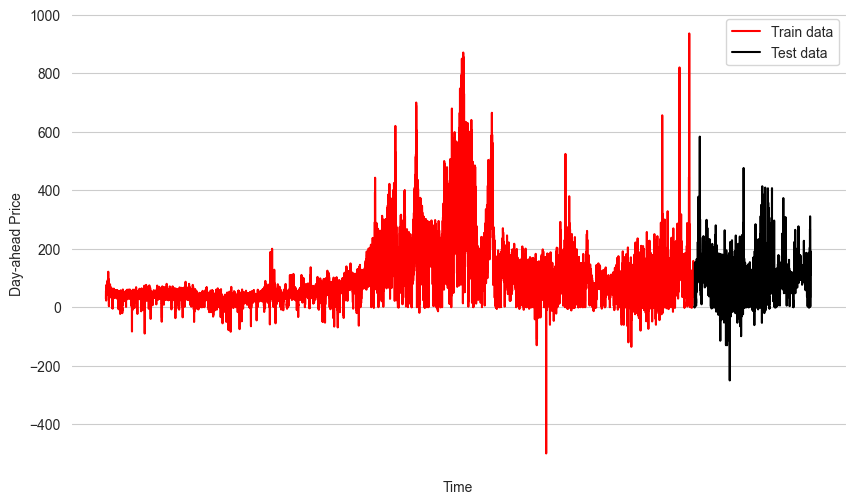

In [225]:
# Split data into train and test sample
# This is the simplest possible split, no cross-validation yet
test_start = "2025-01-01"

train_df = df[df['timestamp'] < test_start].copy()
test_df  = df[df['timestamp'] >= test_start].copy()

# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price')
plt.xticks([])
plt.plot(train_df['price'], 'red', label='Train data')
plt.plot(test_df['price'], 'black', label='Test data')
plt.legend();

### Forecast evaluation

In [226]:
# Define metrics

# Daily Average Error (DAE)
def dae(y_true, y_pred):
    y_true = pd.Series(y_true)
    y_pred = pd.Series(y_pred, index=y_true.index)

    df = pd.DataFrame({"err": np.abs(y_true - y_pred)})
    df["date"] = df.index.floor("D")

    def is_full_day(g):
        return g.index.hour.nunique() == 24

    daily = df.groupby("date").filter(is_full_day)
    return daily.groupby("date")["err"].mean().mean()

# Symmetric Mean Absolute Percentage Error (SMAPE)
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denom != 0
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

In [227]:
# performance of naive prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_naive"])
smape_score = smape(test_df["price"], test_df["price_pred_naive"])
dae_score = dae(test_df.set_index("timestamp")["price"], test_df.set_index("timestamp")["price_pred_naive"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 25.4857
DAE: 25.3498
SMAPE: 43.7526


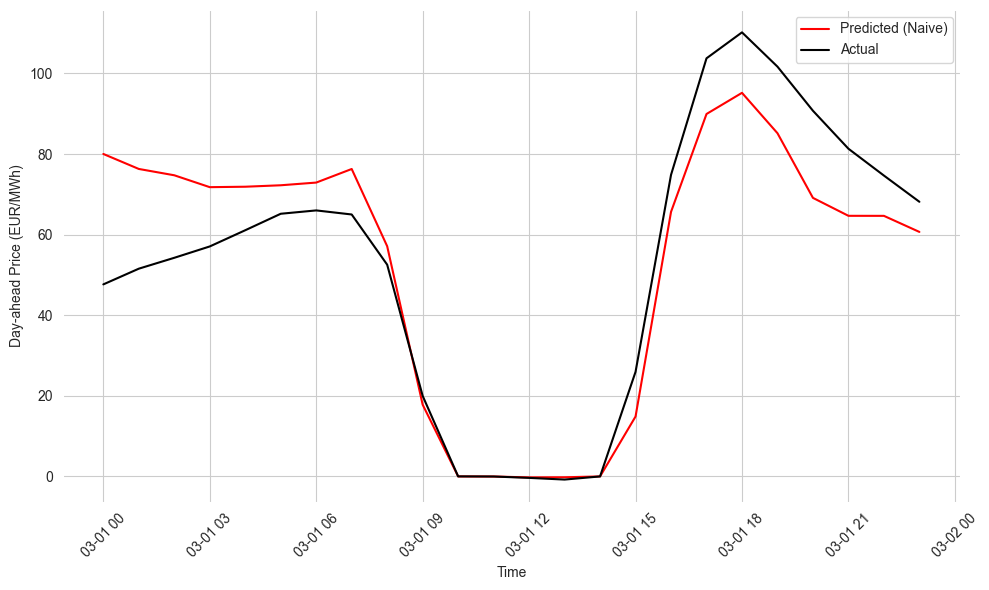

In [ ]:
# Plotting true and forecasted for a specific day

day = "2026-03-03"

day_df = test_df[test_df['timestamp'].dt.date == pd.to_datetime(day).date()]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df['timestamp'], day_df['price_pred_naive'],
         color='red', label='Predicted (Naive)')

plt.plot(day_df['timestamp'], day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ARX-LASSO

In [229]:
# first try with a feature set similar to Biro et al.

# define additional price lags (2 and 3 days ago)
df['price_lag_48h'] = df['price'].shift(48)
df['price_lag_72h'] = df['price'].shift(72)

# lagged (actual) generation
df['generation_48h'] = df['total_generation'].shift(48)
df['generation_72h'] = df['total_generation'].shift(72)
df['generation_168h'] = df['total_generation'].shift(168)

# lagged (actual) net export
df['net_export_48h'] = df['net_export'].shift(48)
df['net_export_72h'] = df['net_export'].shift(72)
df['net_export_168h'] = df['net_export'].shift(168)

In [230]:
lag_cols = [
    'price_lag_24h', 'price_lag_48h', 'price_lag_72h', 'price_lag_168h'
]

In [231]:
# feature set with load fcast and renewable fcast, lags of actual net export, lags of total actual generation, and the time features (sin, cos)
exog_features = [
    'load', 'wind_offshore', 'wind_onshore', 'solar',
    'net_export_48h', 'net_export_72h', 'net_export_168h',
    'generation_48h', 'generation_72h', 'generation_168h'
]

In [232]:
seasonal = [
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos'
]

In [233]:
# Split data into train and test sample
test_start = "2025-01-01"

train_df = df[df['timestamp'] < test_start].copy()
test_df  = df[df['timestamp'] >= test_start].copy()

train_df = train_df.dropna().copy()  # eliminated N/A from train (generated by lagging)

In [234]:
X_train = train_df[lag_cols + exog_features + seasonal]
y_train = train_df['price']

X_test = test_df[lag_cols + exog_features + seasonal]

In [235]:
# Standardize all features and lagged prices  (... shall we do it also on the sin and cosine time effects? )
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [236]:
# fit linear model with Lasso regularization

# experiment with different alphas
lasso = Lasso(alpha=0.5, max_iter=int(10e5))
lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.5, max_iter=1000000)

In [237]:
# predict on test-set
test_df['price_pred_arxlasso'] = lasso.predict(X_test_scaled)

In [238]:
# performance of ARX-LASSO prediction on test sample

mae_score = mae(test_df["price"], test_df["price_pred_arxlasso"])
smape_score = smape(test_df["price"], test_df["price_pred_arxlasso"])
dae_score = dae(test_df.set_index("timestamp")["price"], test_df.set_index("timestamp")["price_pred_arxlasso"])

print(f"MAE: {mae_score:.4f}")
print(f"DAE: {dae_score:.4f}")
print(f"SMAPE: {smape_score:.4f}")

MAE: 18.8658
DAE: 18.8454
SMAPE: 37.1011


In [239]:
# show features with non-zero coefficients (features not dropped by lasso)
coef_series = pd.Series(lasso.coef_, index=lag_cols + exog_features + seasonal)
selected_features = coef_series[coef_series != 0].sort_values(ascending=False)
print(selected_features)

price_lag_24h      49.927307
price_lag_168h     23.041789
load               13.573530
price_lag_72h      13.445903
net_export_48h      7.095560
price_lag_48h       4.655071
dow_cos             3.176137
hour_cos            2.032722
dow_sin             1.204248
net_export_168h     1.160632
hour_sin            0.827694
month_cos           0.148983
net_export_72h      0.010293
wind_offshore      -6.163343
solar              -6.318657
generation_48h     -6.610990
wind_onshore      -15.352733
dtype: float64


In [240]:
discarded_features = coef_series[coef_series == 0].sort_values(ascending=False)
print(discarded_features)

generation_72h    -0.0
generation_168h    0.0
month_sin          0.0
dtype: float64


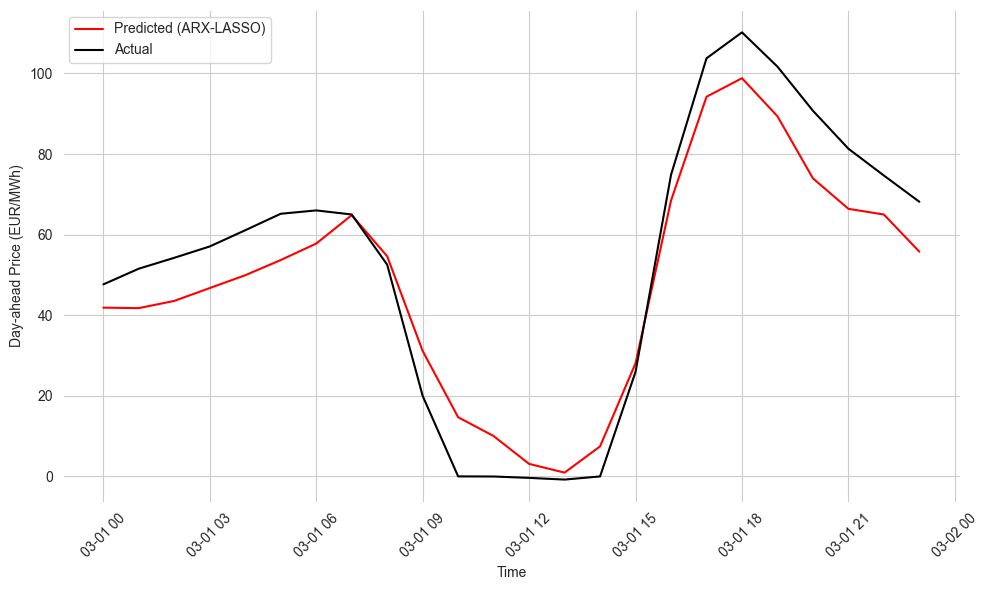

In [ ]:
# Plotting true and forecasted for a specific day

day = "2026-03-03"

day_df = test_df[test_df['timestamp'].dt.date == pd.to_datetime(day).date()]

plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel('Day-ahead Price (EUR/MWh)')

plt.plot(day_df['timestamp'], day_df['price_pred_arxlasso'],
         color='red', label='Predicted (ARX-LASSO)')

plt.plot(day_df['timestamp'], day_df['price'],
         color='black', label='Actual')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## XGBoost